# מטלה מסכמת: מבוא ללמידת מכונה ומדעי הנתונים
- ליעד מנדיל, 315096073
- מקסים פרוקופצוק, 337875397

## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
import math

----------------------------

## Helpfull Functions

In [9]:
def box_data_by_group(df, group_col, value_col):
    tmp = df[[group_col, value_col]].dropna(subset=[group_col, value_col])
    labels = sorted(tmp[group_col].unique())
    data = [tmp.loc[tmp[group_col] == g, value_col].values for g in labels]
    return labels, data

In [10]:
def crosstab_percent(df, row_col, col_col, dropna=True, round_to=2):
    data = df[[row_col, col_col]]
    
    if dropna:
        data = data.dropna(subset=[row_col, col_col])

    table = (
        pd.crosstab(data[row_col], data[col_col], normalize="index") * 100
    ).round(round_to)

    values = table.values
    row_labels = table.index.tolist()
    col_labels = table.columns.tolist()

    return table, values, row_labels, col_labels

In [11]:
def plot_heatmap(values, row_labels, col_labels, title="", xlabel="", ylabel="", fmt=".1f", figsize=(10,4)):
    """
    Draws a heatmap with numbers inside each cell.
    Designed to work with output from crosstab_percent.
    """
    plt.figure(figsize=figsize)
    plt.imshow(values, aspect="auto")

    plt.xticks(range(len(col_labels)), col_labels, rotation=45)
    plt.yticks(range(len(row_labels)), row_labels)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            plt.text(j, i, format(values[i, j], fmt), ha="center", va="center", fontsize=10)

    plt.colorbar(label="Percentage")
    plt.tight_layout()
    plt.show()

In [12]:
def plot_box_subplots(df, cols, group_col, nrows=2, ncols=2, figsize=(12,7), showfliers=True):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, col in zip(axes, cols):
        labels, data = box_data_by_group(df, group_col, col)
        ax.boxplot(data, labels=labels, showfliers=showfliers)
        ax.set_title(f"{col} by {group_col}")
        ax.set_xlabel(group_col)
        ax.set_ylabel(col)

    for ax in axes[len(cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [13]:
def category_distribution(df, filter_col, filter_value, target_col, normalize=True, round_to=2):
    """
    Returns percentage distribution of target_col
    within rows where filter_col == filter_value.
    """
    subset = df[df[filter_col] == filter_value]

    dist = (
        subset[target_col]
        .value_counts(normalize=normalize)
        .mul(100 if normalize else 1)
        .round(round_to)
    )

    return dist


In [14]:
def fill_missing_by_group_unique(df, group_col, target_col):
    def unique_value_or_nan(s):
        s = s.dropna()
        if len(s) == 0:
            return np.nan
        return s.iloc[0] if s.nunique() == 1 else np.nan

    group_map = df.groupby(group_col)[target_col].apply(unique_value_or_nan)

    missing_mask = df[target_col].isna()
    fill_mask = missing_mask & df[group_col].map(group_map).notna()

    df.loc[fill_mask, target_col] = df.loc[fill_mask, group_col].map(group_map)

In [15]:
def missing_table(df, col):
    return pd.DataFrame({
        "Count": [
            df[col].isna().sum(),
            df[col].notna().sum(),
            len(df)
        ]
    }, index=[
        f"{col} is NaN",
        f"{col} not NaN",
        "Total rows"
    ])

In [16]:
def scatter_plot(df, x_col, y_col, mask=None, title="", alpha=0.5, figsize=(8,5)):
    if mask is not None:
        data = df.loc[mask, [x_col, y_col]]
    else:
        data = df[[x_col, y_col]].dropna()

    plt.figure(figsize=figsize)
    plt.scatter(data[x_col], data[y_col], alpha=alpha)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


-------------------------------

## חלק ראשון: אימון והערכת ביצועי מסווגים

## טעינה ראשונית של המידע

In [17]:
spaceship_data = pd.read_csv('Spaceship_data.csv')
print(spaceship_data.shape)

(8693, 14)


#### הצגת מידע על הדאטה


In [18]:
spaceship_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


בדיקת ייחודיות

In [19]:
spaceship_data.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

#### הצגת ראש המסמך

In [20]:
spaceship_data.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


הצגת היסטוגרמה

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

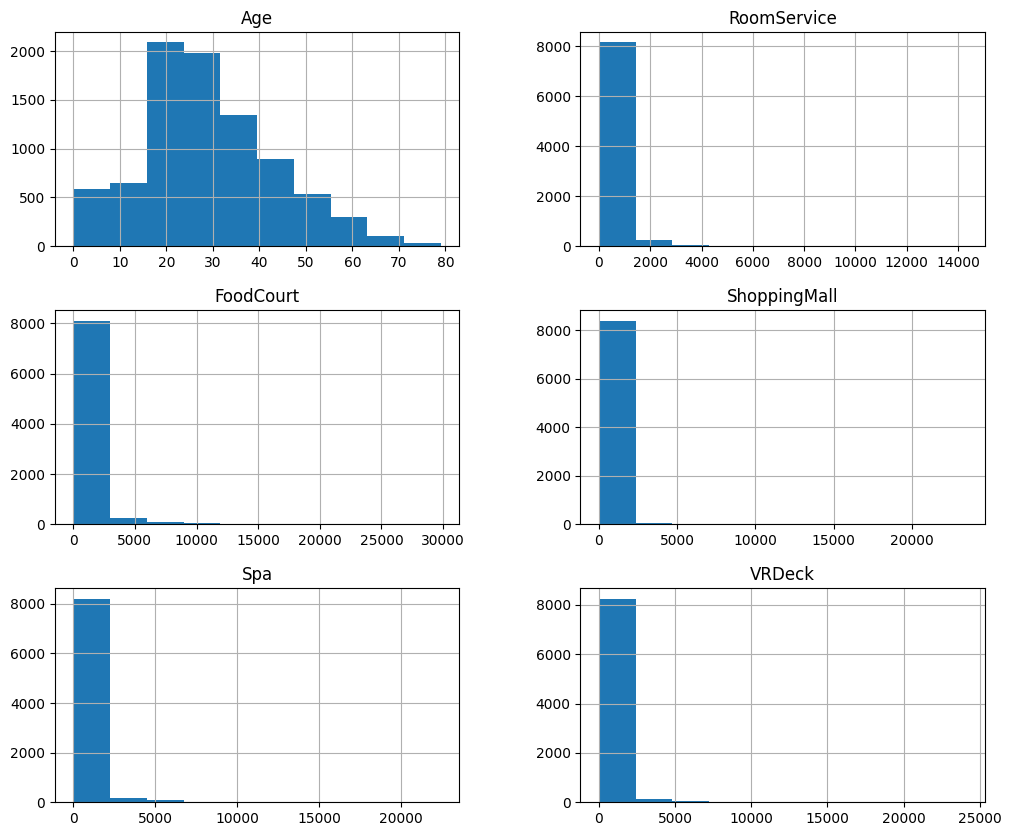

In [21]:
spaceship_data.hist(figsize=(12,10))

##### הצגת התפלגויות מספריים

In [22]:
## sns.pairplot(spaceship_data)

## חקר + שינוי טייפ הדאטה למספרים

In [23]:
spaceship_data_copy = spaceship_data.copy()

#### TotalSpend

In [24]:
spaceship_data_copy['TotalSpend'] = (
    spaceship_data_copy[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']]
    .fillna(0)
    .sum(axis=1)
)

#### homeplanet

נתונים ראשוניים:

In [25]:
counts = spaceship_data_copy["HomePlanet"].value_counts()
print(counts)

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


<Axes: title={'center': 'HomePlanet Distribution'}>

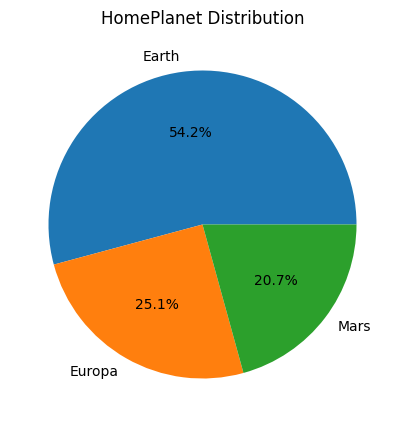

In [26]:
counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    title='HomePlanet Distribution',
    ylabel='',
)

##### מילון המרה משמות למספרים

In [27]:
homeplanet_map = {
    'Earth': 0,
    'Europa': 1,
    'Mars': 2
}

##### החלפת השמות בעזרת המילון

In [28]:
spaceship_data_copy['HomePlanet'] = (
    spaceship_data_copy['HomePlanet']
    .map(homeplanet_map)
    .fillna(-1)
    .astype(int)
)

--------------------------------


#### destination

בדיקה כמה אופציות יש

In [29]:
counts = spaceship_data_copy["Destination"].value_counts()
print(counts)

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64


הצגתם

<Axes: title={'center': 'Destination Distribution'}>

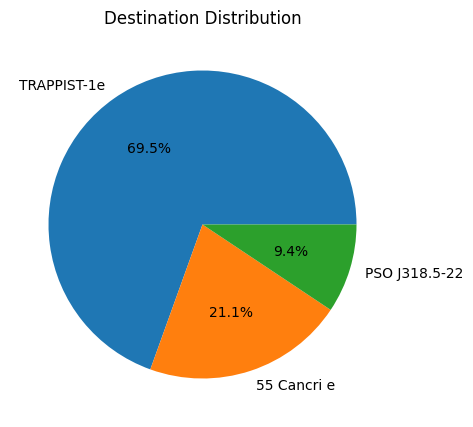

In [30]:
counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    title='Destination Distribution',
    ylabel='',
)

##### יצירת מילון

In [31]:
destination_map = {
    'TRAPPIST-1e': 0,
    'PSO J318.5-22': 1,
    '55 Cancri e': 2
}

##### החלפת שמות במספרים

In [32]:
spaceship_data_copy['Destination'] = (
    spaceship_data_copy['Destination']
    .map(destination_map)
    .fillna(-1)
    .astype(int)
)

----------------------------


#### cryosleep

התפלגות

In [33]:
counts = spaceship_data_copy["CryoSleep"].value_counts()
print(counts)

CryoSleep
False    5439
True     3037
Name: count, dtype: int64


<Axes: title={'center': 'CryoSleep Distribution'}>

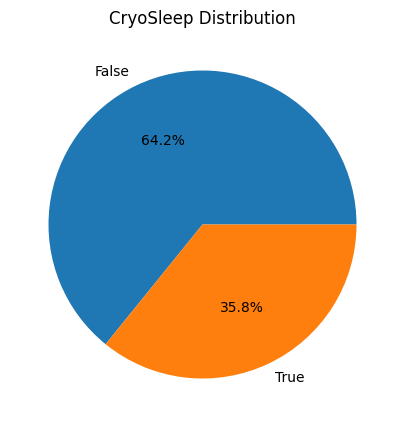

In [34]:
counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    title='CryoSleep Distribution',
    ylabel='',
)

המרה ממשתנה בוליאני לאינטגרים

In [35]:
spaceship_data_copy['CryoSleep'] = spaceship_data_copy['CryoSleep'].map({True: 1, False: 0}).fillna(-1).astype(int)

----------------------------------

####  VIP

התפלגות

In [36]:
counts = spaceship_data_copy["VIP"].value_counts()
print(counts)

VIP
False    8291
True      199
Name: count, dtype: int64


<Axes: title={'center': 'VIP Distribution'}>

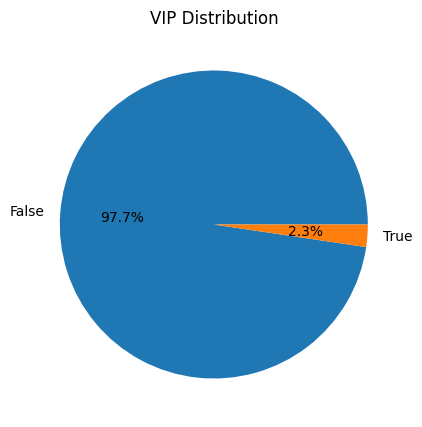

In [37]:
counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    title='VIP Distribution',
    ylabel='',
)

החלפת משתנה בוליאני במשתנה מספרי

In [38]:
spaceship_data_copy['VIP'] = spaceship_data_copy['VIP'].map({True: 1, False: 0}).fillna(-1).astype(int)

-----------------------------

####  Transported

שינוי משתנה בוליאני במשתנה מספרי

In [39]:
spaceship_data_copy['Transported'] = spaceship_data_copy['Transported'].map({True: 1, False: 0}).fillna(-1).astype(int)

---------------------------------

####  PassengerID

 בדיקת ייחודיות שלא יש כפילויות

In [40]:
id_check = spaceship_data_copy['PassengerId'].value_counts()
print(id_check[id_check > 1])

Series([], Name: count, dtype: int64)


 בדיקת תקינות שהמילון לא יתקע

In [41]:
pattern = r'^\d{4}_\d{2}$'
invalid_ids = spaceship_data_copy[~spaceship_data_copy['PassengerId'].str.match(pattern)]
print(invalid_ids)

Empty DataFrame
Columns: [PassengerId, HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Name, Transported, TotalSpend]
Index: []


 פיצול העמודה ל2 עמודות:
- PassengerId ->  GroupId, GroupMemberId

In [42]:
spaceship_data_copy['GroupId'] = spaceship_data_copy['PassengerId'].str.split('_').str[0]
spaceship_data_copy['GroupMemberId'] = spaceship_data_copy['PassengerId'].str.split('_').str[1]

spaceship_data_copy['GroupId'] = spaceship_data_copy['GroupId'].astype(int)
spaceship_data_copy['GroupMemberId'] = spaceship_data_copy['GroupMemberId'].astype(int)

spaceship_data_copy.drop(columns=['PassengerId'], inplace=True)

-----------------------------------------

#### שינוי Cabin

 בדיקת תקינות 

In [43]:
pattern =  r'^[A-GT]/\d+/(P|S)$'
is_valid = (
    spaceship_data_copy['Cabin'].isna() |
    spaceship_data_copy['Cabin'].str.match(pattern)
)

In [44]:
validity_summary = (
    is_valid
    .value_counts()
    .rename({True: 'Valid (or NaN)', False: 'Invalid'})
    .reset_index()
)

validity_summary.columns = ['Cabin_validity', 'Count']
validity_summary

,Cabin_validity,Count
0,Valid (or NaN),8693


 פיצול הCABIN למידע:
 - Cabin -> Deck,RoomNum,RoomSide

In [45]:
spaceship_data_copy['Deck'] = spaceship_data['Cabin'].str.split('/').str[0]
spaceship_data_copy['RoomNum'] = spaceship_data['Cabin'].str.split('/').str[1]
spaceship_data_copy['RoomSide'] = spaceship_data['Cabin'].str.split('/').str[2]

spaceship_data_copy['RoomNum'] = spaceship_data_copy['RoomNum'].astype('float64')

In [46]:
deck_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4,
    'F': 5,
    'G': 6,
    'T': 7
}

roomside_map = {
    'P': 0,
    'S': 1,
}

In [47]:
spaceship_data_copy['Deck'] = (
    spaceship_data_copy['Deck']
    .map(deck_map)
    .fillna(-1)
    .astype(int)
)

spaceship_data_copy['RoomSide'] = (
    spaceship_data_copy['RoomSide']
    .map(roomside_map)
    .fillna(-1)
    .astype(int)
)

------------------------------

####  Name

פיצול השם לשם פרטי ושם משפחה

In [48]:
spaceship_data_copy[['FirstName', 'Surname']] = spaceship_data['Name'].str.split(' ', expand=True)

##### בדיקת שלכולם יש 2 שמות

In [49]:
name_vector = spaceship_data['Name']

is_valid_name = (
    name_vector.isna() |                       # NaN תקין
    name_vector.str.match(r'^[^ ]+ [^ ]+$', na=False)
)

In [50]:
name_validity_table = (
    is_valid_name
    .value_counts()
    .rename({True: 'Valid (two words)', False: 'Invalid'})
    .to_frame(name='Count')
)

name_validity_table


,Count
Name,
Valid (two words),8693


-------------------------------

#### Age 

התפלגות גילאים

Text(0.5, 1.0, 'Age Distribution')

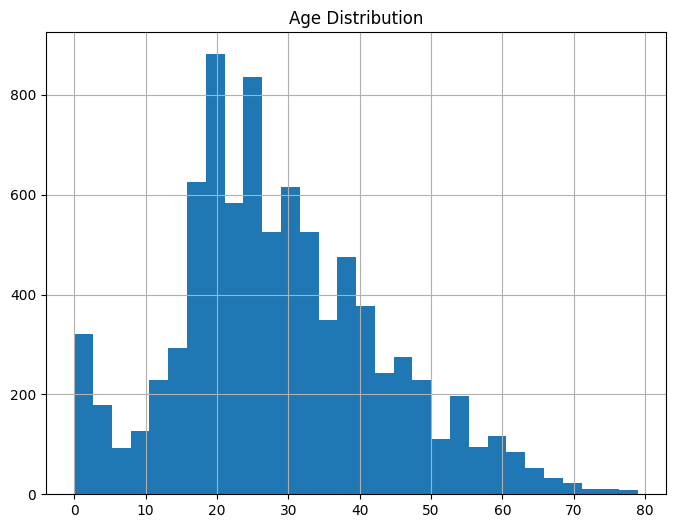

In [51]:
ax = spaceship_data_copy['Age'].hist(figsize=(8,6), bins=30)
ax.set_title('Age Distribution')

-------------------------------

#### RoomService 

##### התפלגות

Text(0.5, 1.0, 'Room Service Distribution')

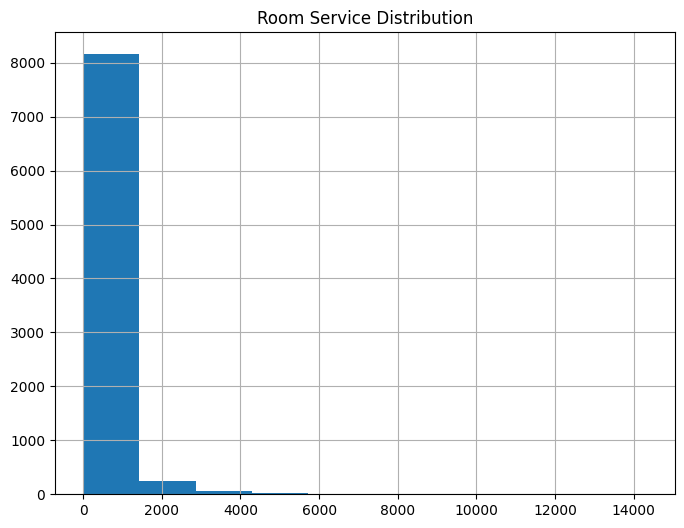

In [52]:
ax = spaceship_data_copy['RoomService'].hist(figsize=(8,6))
ax.set_title('Room Service Distribution')

#### FoodCourt

##### התפלגות

Text(0.5, 1.0, 'FoodCourt Distribution')

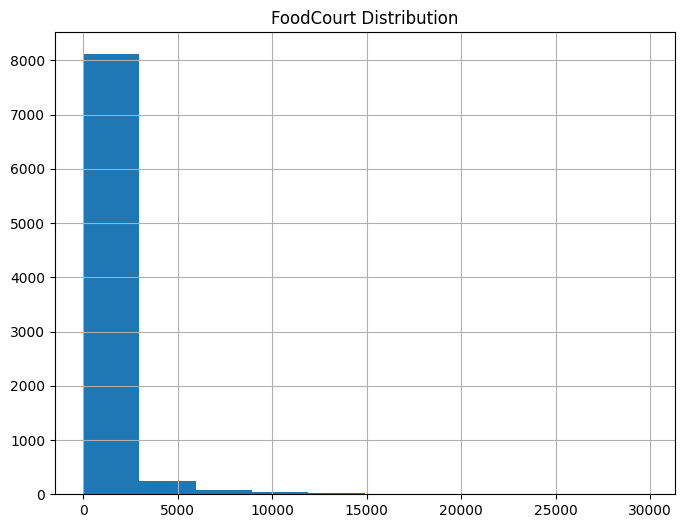

In [53]:
ax = spaceship_data_copy['FoodCourt'].hist(figsize=(8,6))
ax.set_title('FoodCourt Distribution')

#### ShoppingMall

##### התפלגות

Text(0.5, 1.0, 'Shopping Mall Distribution')

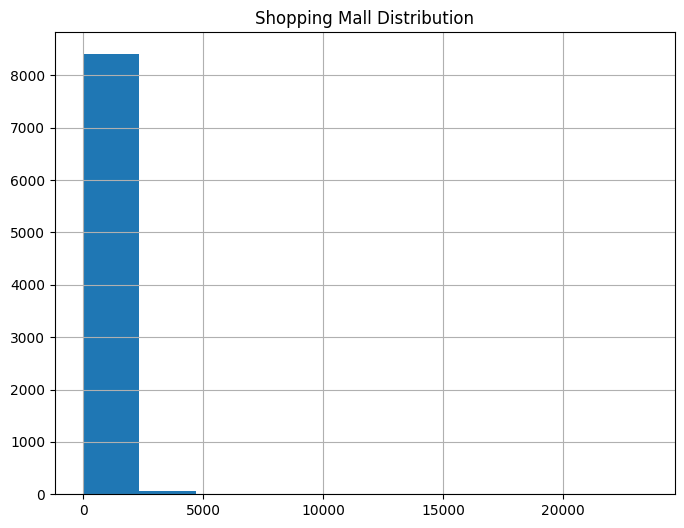

In [54]:
ax = spaceship_data_copy['ShoppingMall'].hist(figsize=(8,6))
ax.set_title('Shopping Mall Distribution')

#### Spa

##### התפלגות

Text(0.5, 1.0, 'Spa Distribution')

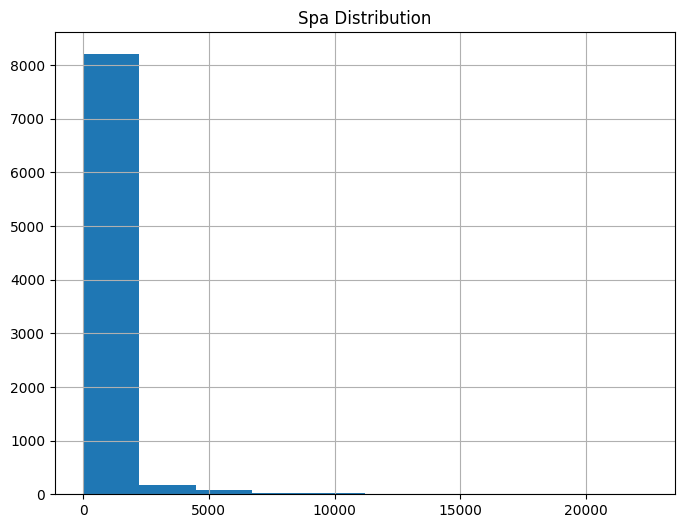

In [55]:
ax = spaceship_data_copy['Spa'].hist(figsize=(8,6))
ax.set_title('Spa Distribution')

#### VRDeck

##### התפלגות

Text(0.5, 1.0, 'VR Deck Distribution')

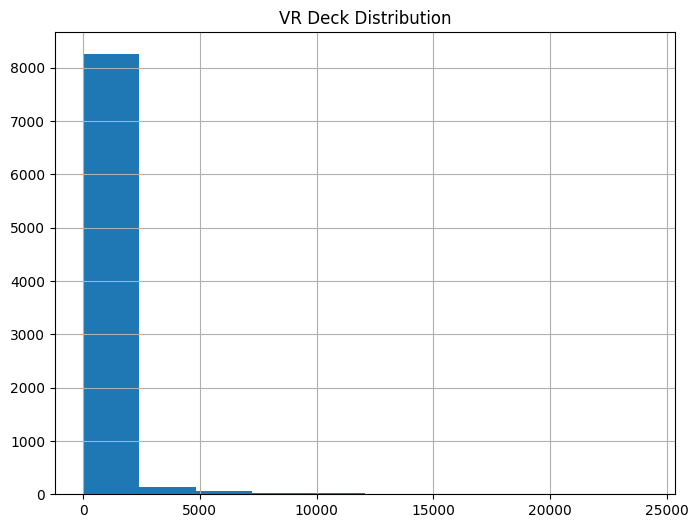

In [56]:
ax = spaceship_data_copy['VRDeck'].hist(figsize=(8,6))
ax.set_title('VR Deck Distribution')

#### החזרת מידע חסר

In [57]:
spaceship_data = spaceship_data_copy.copy()
spaceship_data.replace(-1, np.nan, inplace=True)
spaceship_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     8492 non-null   float64
 1   CryoSleep      8476 non-null   float64
 2   Cabin          8494 non-null   object 
 3   Destination    8511 non-null   float64
 4   Age            8514 non-null   float64
 5   VIP            8490 non-null   float64
 6   RoomService    8512 non-null   float64
 7   FoodCourt      8510 non-null   float64
 8   ShoppingMall   8485 non-null   float64
 9   Spa            8510 non-null   float64
 10  VRDeck         8505 non-null   float64
 11  Name           8493 non-null   object 
 12  Transported    8693 non-null   int64  
 13  TotalSpend     8693 non-null   float64
 14  GroupId        8693 non-null   int64  
 15  GroupMemberId  8693 non-null   int64  
 16  Deck           8494 non-null   float64
 17  RoomNum        8494 non-null   float64
 18  RoomSide

## מציאת ערכים חסרים בדאטה

### HomePlanet

homeplanet_map = {
    'Earth': 0,
    'Europa': 1,
    'Mars': 2
}

In [58]:
missing_table(spaceship_data, "HomePlanet")

,Count
HomePlanet is NaN,201
HomePlanet not NaN,8492
Total rows,8693


#### הצגת המידע בחיתוכים עם יתר הדאטה:

בדיקת הוצאת כספים לפי כוכב אם

In [59]:
money_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
money_cols = [c for c in money_cols if c in spaceship_data.columns]

In [60]:
money_summary_table = (
    spaceship_data
    .dropna(subset=["HomePlanet"])
    .groupby("HomePlanet")[money_cols]
    .agg(["count", "mean", "median"])
    .round(2)
)

money_summary_table.columns = [f"{col}_{stat}" for col, stat in money_summary_table.columns]
money_summary_table

,RoomService_count,RoomService_mean,RoomService_median,FoodCourt_count,FoodCourt_mean,FoodCourt_median,ShoppingMall_count,ShoppingMall_mean,ShoppingMall_median,Spa_count,Spa_mean,Spa_median,VRDeck_count,VRDeck_mean,VRDeck_median
HomePlanet,,,,,,,,,,,,,,,
0.0,4499,136.94,0.0,4505,137.23,0.0,4490,133.87,0.0,4503,142.78,0.0,4491,138.13,0.0
1.0,2095,145.23,0.0,2085,1503.21,13.0,2078,151.13,0.0,2086,848.06,0.0,2094,875.77,0.0
2.0,1723,552.90,25.0,1721,54.36,0.0,1723,308.45,0.0,1723,110.22,0.0,1720,47.44,0.0


C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter o

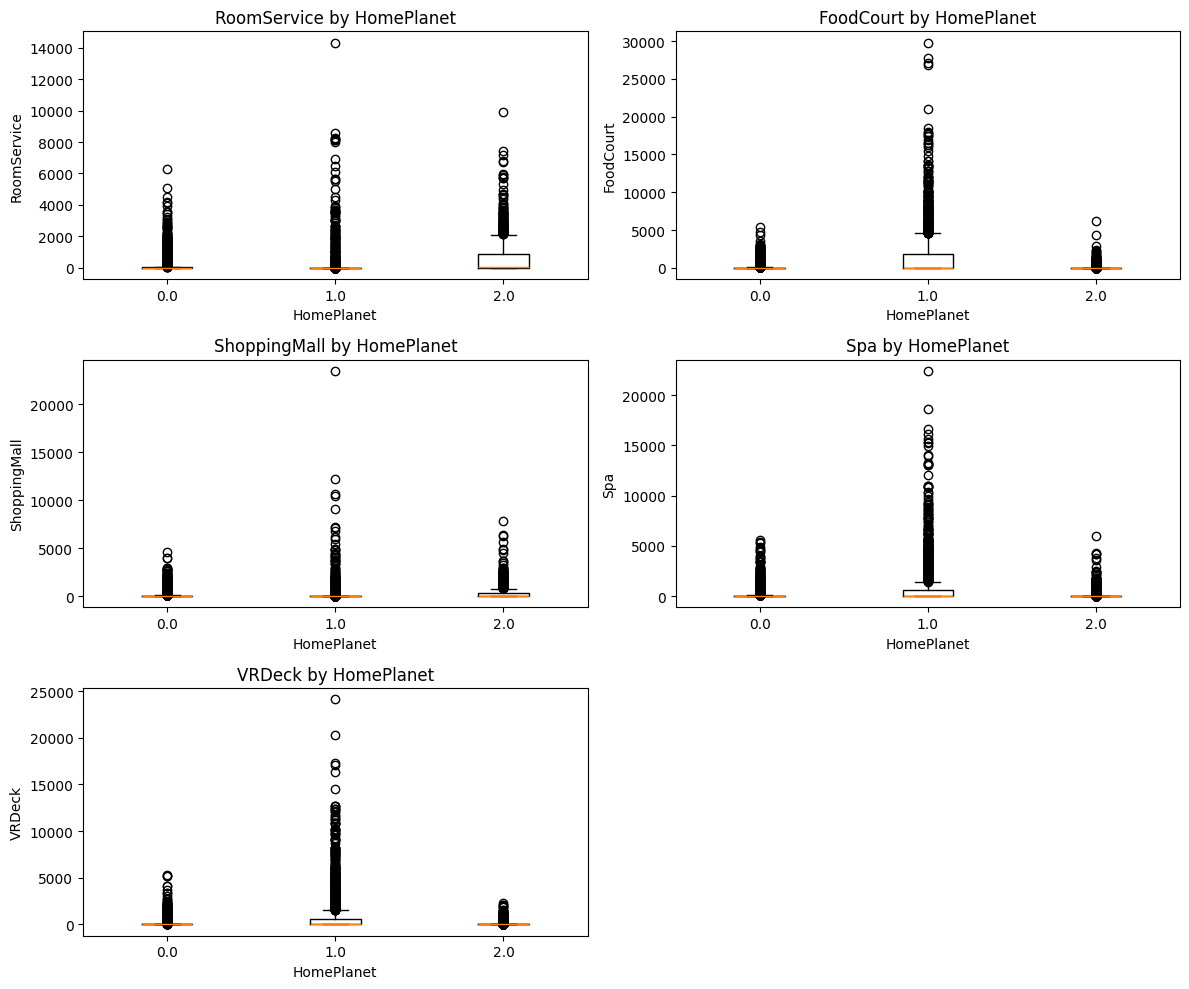

In [61]:
plot_box_subplots(spaceship_data, money_cols, "HomePlanet", nrows=3, ncols=2, figsize=(12,10))

בדיקת יעד לכל כוכב אם באחוזים

In [62]:
dest_table, dest_values, dest_rows, dest_cols = crosstab_percent(
    spaceship_data, "HomePlanet", "Destination"
)

dest_table

Destination,0.0,1.0,2.0
HomePlanet,,,
0.0,68.87,15.81,15.32
1.0,56.78,0.91,42.31
2.0,85.91,2.85,11.24


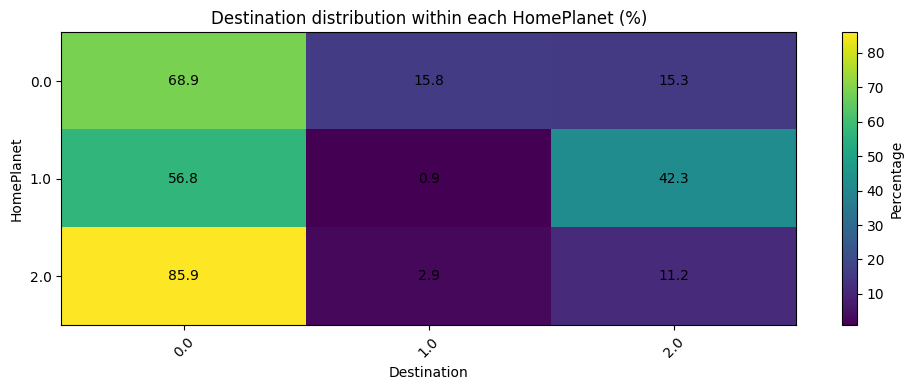

In [63]:
plot_heatmap(
    dest_values,
    dest_rows,
    dest_cols,
    title="Destination distribution within each HomePlanet (%)",
    xlabel="Destination",
    ylabel="HomePlanet"
)

##### הוספת כוכב אם 2 לאנשים שהיעד שלהם הוא כוכב 0 בסבירות של 86 אחוז

In [64]:
mask = (spaceship_data["HomePlanet"].isna()) & (spaceship_data["Destination"] == 0)

In [65]:
spaceship_data.loc[mask, "HomePlanet"] = 2

In [66]:
missing_table(spaceship_data, "HomePlanet")

,Count
HomePlanet is NaN,51
HomePlanet not NaN,8642
Total rows,8693


בדיקת שכיחת טווח גילאים מכל כוכב אם

In [67]:
# יצירת AgeBin על הדאטה המקורי
bins = [0,10,20,30,40,50,60,70,80,200]
labels = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80+"]

spaceship_data['AgeBin'] = pd.cut(
    spaceship_data['Age'],
    bins=bins,
    labels=labels,
    right=False
)

In [68]:
# טבלת אחוזים: AgeBin בתוך HomePlanet
age_table, age_values, age_rows, age_cols = crosstab_percent(
    spaceship_data, "HomePlanet", "AgeBin"
)

age_table

AgeBin,0-9,10-19,20-29,30-39,40-49,50-59,60-69,70-79
HomePlanet,,,,,,,,
0.0,10.68,21.95,34.32,15.84,9.73,5.07,2.02,0.40
1.0,1.77,9.45,29.21,28.35,17.27,9.88,3.36,0.72
2.0,8.48,14.97,31.65,22.42,13.09,6.17,2.52,0.70


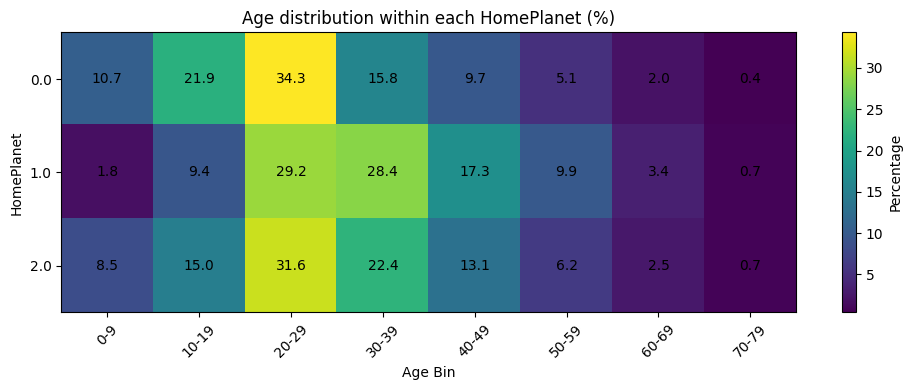

In [69]:
# Heatmap
plot_heatmap(
    age_values,
    age_rows,
    age_cols,
    title="Age distribution within each HomePlanet (%)",
    xlabel="Age Bin",
    ylabel="HomePlanet"
)

In [70]:
spaceship_data = spaceship_data.drop(columns=['AgeBin'])

בדיקה כמה אחוז מהוי איי פי הכל כוכב אם

In [71]:
vip_homeplanet_pct = category_distribution(
    spaceship_data,
    filter_col="VIP",
    filter_value=1,
    target_col="HomePlanet"
)

vip_homeplanet_pct

HomePlanet
1.0    66.5
2.0    33.5
Name: proportion, dtype: float64

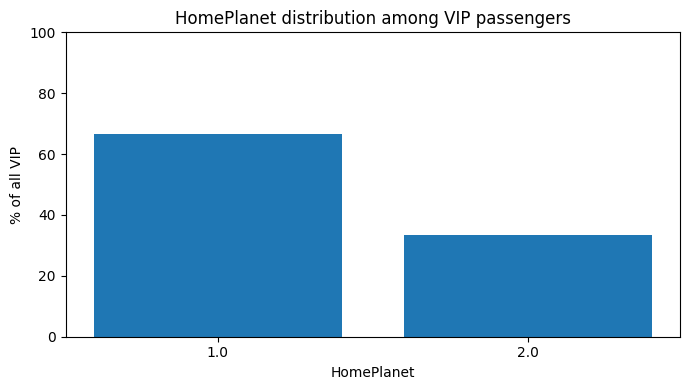

In [72]:
plt.figure(figsize=(7, 4))
plt.bar(vip_homeplanet_pct.index.astype(str), vip_homeplanet_pct.values)

plt.ylabel("% of all VIP")
plt.xlabel("HomePlanet")
plt.title("HomePlanet distribution among VIP passengers")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

בדיקת צד בספינה

In [73]:
side_table, side_values, side_rows, side_cols = crosstab_percent(
    spaceship_data, "HomePlanet", "RoomSide"
)

side_table

RoomSide,0.0,1.0
HomePlanet,,
0.0,50.37,49.63
1.0,46.14,53.86
2.0,51.39,48.61


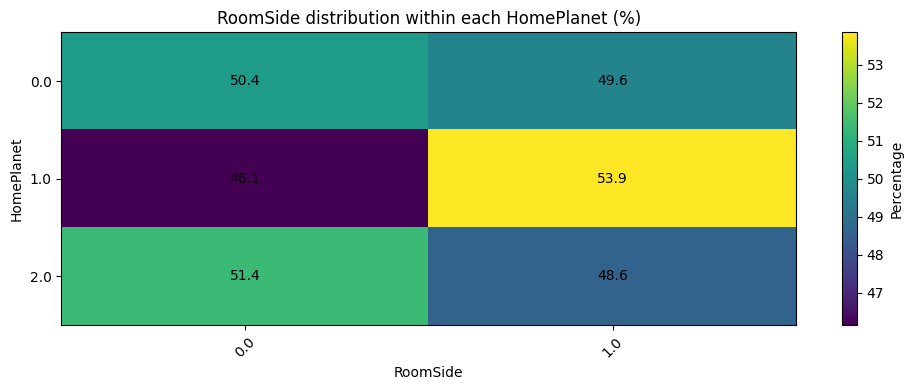

In [74]:
plot_heatmap(
    side_values,
    side_rows,
    side_cols,
    title="RoomSide distribution within each HomePlanet (%)",
    xlabel="RoomSide",
    ylabel="HomePlanet"
)

##### מציאת קבוצת כל אחד מהנוסעים ללא  homeplanet

In [75]:
missing_before = spaceship_data["HomePlanet"].isna().sum()
fill_missing_by_group_unique(spaceship_data, "GroupId", "HomePlanet")
missing_after = spaceship_data["HomePlanet"].isna().sum()

filled_values = missing_before - missing_after

summary_df = pd.DataFrame({
    "Metric": [
        "Missing before filling",
        "Values filled",
        "Missing after filling",
        "Fill rate (%)"
    ],
    "Value": [
        missing_before,
        filled_values,
        missing_after,
        round(100 * filled_values / missing_before, 2)
    ]
})

display(summary_df)


,Metric,Value
0,Missing before filling,51.00
1,Values filled,19.00
2,Missing after filling,32.00
3,Fill rate (%),37.25


##### בדיקת קשר ביו קומה בספינה לבין כוכב אם

In [76]:
deck_hp_table, deck_hp_values, deck_hp_rows, deck_hp_cols = crosstab_percent(
    spaceship_data, "Deck", "HomePlanet"
)

deck_hp_table

HomePlanet,0.0,1.0,2.0
Deck,,,
0.0,0.00,99.22,0.78
1.0,0.00,98.97,1.03
2.0,0.00,98.79,1.21
3.0,0.00,39.50,60.50
4.0,45.30,14.79,39.91
5.0,57.95,0.00,42.05
6.0,98.35,0.00,1.65
7.0,0.00,80.00,20.00


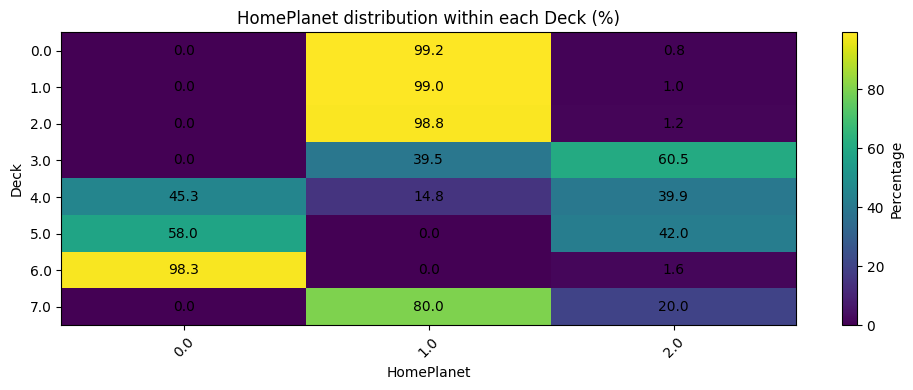

In [77]:
plot_heatmap(
    deck_hp_values,
    deck_hp_rows,
    deck_hp_cols,
    title="HomePlanet distribution within each Deck (%)",
    xlabel="HomePlanet",
    ylabel="Deck"
)


<div dir="rtl" style="text-align: left;">
    בDeck A,B,C,T תמיד גרים אנשים מEuropa וG זה תמיד Earth
</div>

In [78]:
missing_before = spaceship_data['HomePlanet'].isna().sum()

In [79]:
mask_europa = (
    spaceship_data['HomePlanet'].isna() &
    spaceship_data['Deck'].isin([0, 1, 2, 7])
)
spaceship_data.loc[mask_europa, 'HomePlanet'] = 1  # Europa

mask_earth = (
    spaceship_data['HomePlanet'].isna() &
    (spaceship_data['Deck'] == 6)
)
spaceship_data.loc[mask_earth, 'HomePlanet'] = 0  # Earth

In [80]:
missing_table(spaceship_data, "HomePlanet")

,Count
HomePlanet is NaN,15
HomePlanet not NaN,8678
Total rows,8693


------------------------

### CryoSleep

In [81]:
missing_table(spaceship_data, "CryoSleep")

,Count
CryoSleep is NaN,217
CryoSleep not NaN,8476
Total rows,8693


##### בדיקת קשר בין שינה ליתר העמודות 

קשר עם כוכב אם

In [82]:
# טבלת אחוזים: CryoSleep בתוך HomePlanet
cs_table, cs_values, cs_rows, cs_cols = crosstab_percent(
    spaceship_data, "HomePlanet", "CryoSleep"
)

cs_table

CryoSleep,0.0,1.0
HomePlanet,,
0.0,69.12,30.88
1.0,55.90,44.10
2.0,61.49,38.51


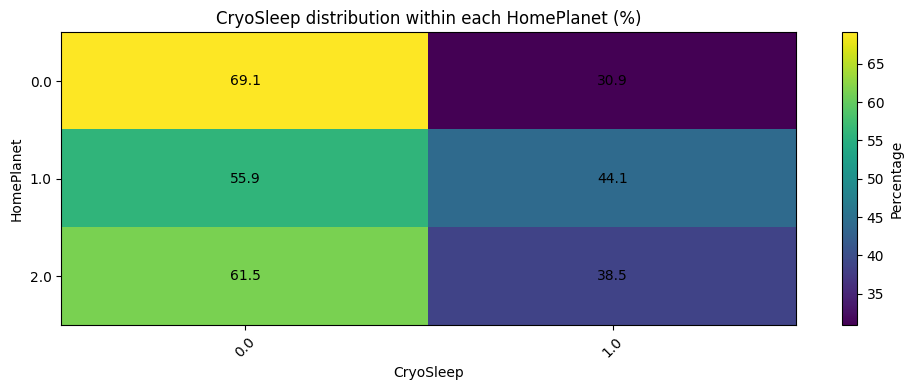

In [83]:
# Heatmap
plot_heatmap(
    cs_values,
    cs_rows,
    cs_cols,
    title="CryoSleep distribution within each HomePlanet (%)",
    xlabel="CryoSleep",
    ylabel="HomePlanet"
)


קשר עם יעד

In [84]:
# טבלת אחוזים: CryoSleep בתוך Destination
cs_dest_table, cs_dest_values, cs_dest_rows, cs_dest_cols = crosstab_percent(
    spaceship_data, "Destination", "CryoSleep"
)

cs_dest_table

CryoSleep,0.0,1.0
Destination,,
0.0,67.61,32.39
1.0,50.71,49.29
2.0,57.92,42.08


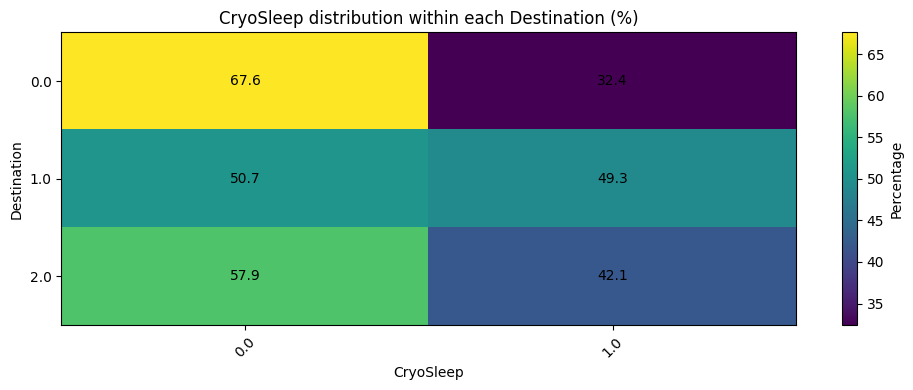

In [85]:
# Heatmap
plot_heatmap(
    cs_dest_values,
    cs_dest_rows,
    cs_dest_cols,
    title="CryoSleep distribution within each Destination (%)",
    xlabel="CryoSleep",
    ylabel="Destination"
)


קשר עם וי איי פי

In [86]:
# טבלת אחוזים: CryoSleep בתוך VIP
vip_cs_table, vip_cs_values, vip_cs_rows, vip_cs_cols = crosstab_percent(
    spaceship_data, "VIP", "CryoSleep"
)

vip_cs_table

CryoSleep,0.0,1.0
VIP,,
0.0,63.62,36.38
1.0,89.29,10.71


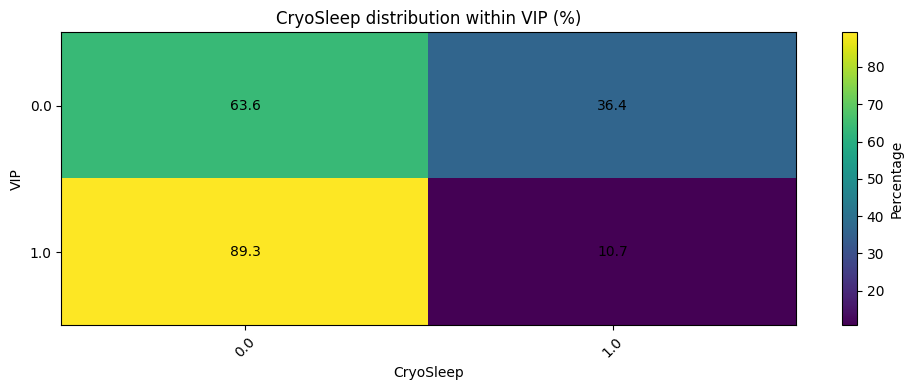

In [87]:
# Heatmap
plot_heatmap(
    vip_cs_values,
    vip_cs_rows,
    vip_cs_cols,
    title="CryoSleep distribution within VIP (%)",
    xlabel="CryoSleep",
    ylabel="VIP"
)

89 אחוז מהוי איי פי לא ישנים ולכן נמלא 

In [88]:
mask = (
    spaceship_data["CryoSleep"].isna() &
    (spaceship_data["VIP"] == 1)
)

print("Rows to be filled:", mask.sum())

Rows to be filled: 3


In [89]:
spaceship_data.loc[mask, "CryoSleep"] = 0

קשר עם הוצאות

C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)
C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter o

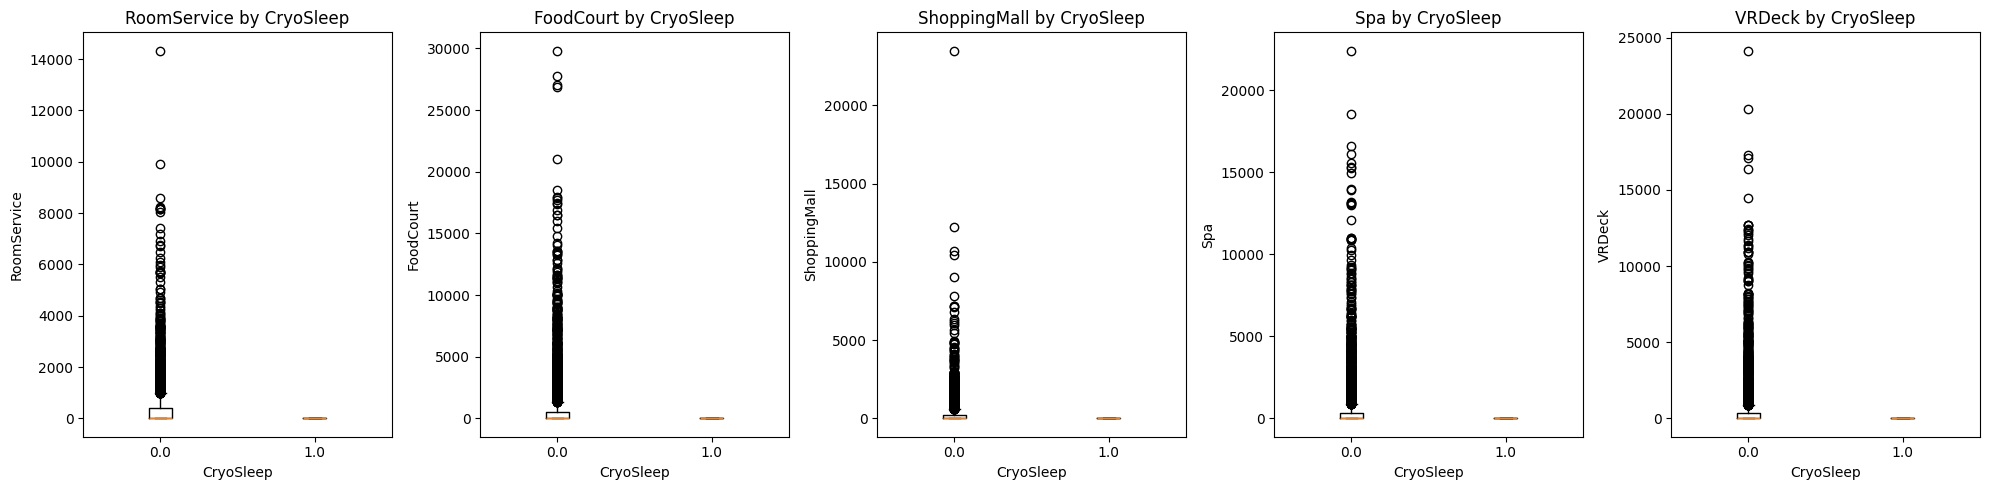

In [90]:
plot_box_subplots(spaceship_data, money_cols, "CryoSleep", nrows=1, ncols=5, figsize=(20,5))


In [91]:
spenders_mask = (
    spaceship_data['CryoSleep'].isna() &
    (spaceship_data['TotalSpend'] > 0)
)

filled_count = spenders_mask.sum()

spaceship_data.loc[spenders_mask, 'CryoSleep'] = 0

print(f"Waking up money spenders: {filled_count}")


Waking up money spenders: 116


In [92]:
deck_cs_table, deck_cs_values, deck_cs_rows, deck_cs_cols = crosstab_percent(
    spaceship_data, "Deck", "CryoSleep"
)

deck_cs_table


CryoSleep,0.0,1.0
Deck,,
0.0,73.12,26.88
1.0,45.58,54.42
2.0,60.00,40.00
3.0,78.15,21.85
4.0,80.65,19.35
5.0,80.18,19.82
6.0,46.34,53.66
7.0,100.00,0.00


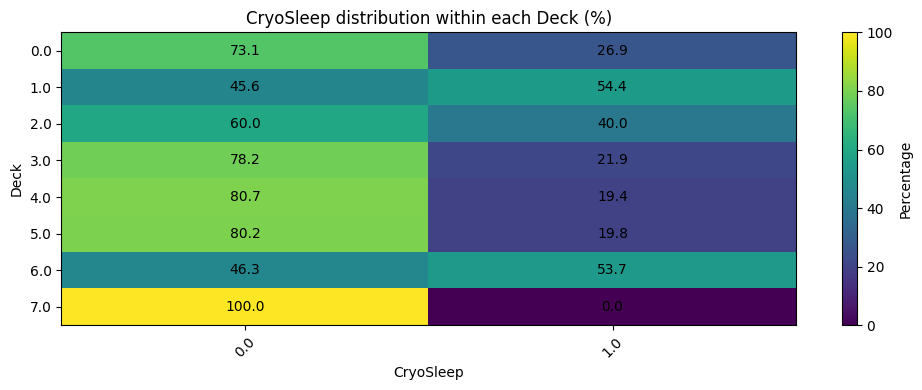

In [93]:
# Heatmap
plot_heatmap(
    deck_cs_values,
    deck_cs_rows,
    deck_cs_cols,
    title="CryoSleep distribution within each Deck (%)",
    xlabel="CryoSleep",
    ylabel="Deck"
)


הכנסת קומות לשינה: T F E D

In [94]:
mask_fill_0 = spaceship_data['CryoSleep'].isna() & spaceship_data['Deck'].isin([0, 3, 4, 5, 7])
count_fill_0 = mask_fill_0.sum()

spaceship_data.loc[mask_fill_0, 'CryoSleep'] = 0

print(f"Filled CryoSleep=0 by Deck (A/D/E/F/T): {count_fill_0}")


Filled CryoSleep=0 by Deck (A/D/E/F/T): 32


בדיקת צד חדר

In [95]:
# טבלת אחוזים: CryoSleep בתוך RoomSide
rs_cs_table, rs_cs_values, rs_cs_rows, rs_cs_cols = crosstab_percent(
    spaceship_data, "RoomSide", "CryoSleep"
)

rs_cs_table

CryoSleep,0.0,1.0
RoomSide,,
0.0,66.00,34.00
1.0,63.96,36.04


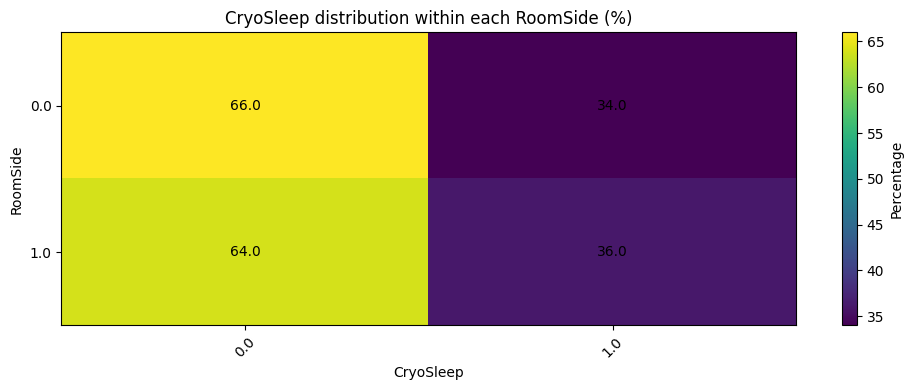

In [96]:
# Heatmap
plot_heatmap(
    rs_cs_values,
    rs_cs_rows,
    rs_cs_cols,
    title="CryoSleep distribution within each RoomSide (%)",
    xlabel="CryoSleep",
    ylabel="RoomSide"
)


בדיקת לפי קבוצה

In [97]:
def all_neighbors_sleep(x):
    # Alone or all NaN - false
    if x.count() == 0:
        return False
    # 1 neighbour not sleeps (0) - false
    if (x == 0).any():
        return False
    # all known neighbours sleep (1) - true
    return True

קבוצת ישנים

In [ ]:
# Group check - if all other group members (with known CryoSleep) sleep, fill as sleeps (1)
group_sleeps = spaceship_data.groupby('GroupId')['CryoSleep'].transform(all_neighbors_sleep)

קבינת ישנים

In [ ]:
# Cabin check (where not NaN) - if all other cabin members (with known CryoSleep) sleep, fill as sleeps (1)
if 'Cabin' in spaceship_data.columns:
    cabin_sleeps = spaceship_data.groupby('Cabin')['CryoSleep'].transform(all_neighbors_sleep)
else:
    cabin_sleeps = pd.Series(False, index=spaceship_data.index)

כל הקנדידתים אפשריים

In [100]:
# CryoSleep empty + spendings 0 + whole group OR whole cabin sleeps = candidates for filling as sleeps (1)
candidates = (
    spaceship_data['CryoSleep'].isna() &
    (spaceship_data['TotalSpend'] == 0) &
    (group_sleeps | cabin_sleeps)
)

spaceship_data.loc[candidates, 'CryoSleep'] = 1

print(f"Changed to sleeps: {int(candidates.sum())}")

remaining_cryo = int(spaceship_data['CryoSleep'].isna().sum())
print(f"NaNs in CryoSleep: {remaining_cryo}")

Changed to sleeps: 9
NaNs in CryoSleep: 57


בדיקה לפי יעד סופי

In [101]:
# טבלת אחוזים: CryoSleep בתוך HomePlanet
cs_hp_table, cs_hp_values, cs_hp_rows, cs_hp_cols = crosstab_percent(
    spaceship_data, "HomePlanet", "CryoSleep"
)

cs_hp_table

CryoSleep,0.0,1.0
HomePlanet,,
0.0,69.50,30.50
1.0,56.59,43.41
2.0,62.38,37.62


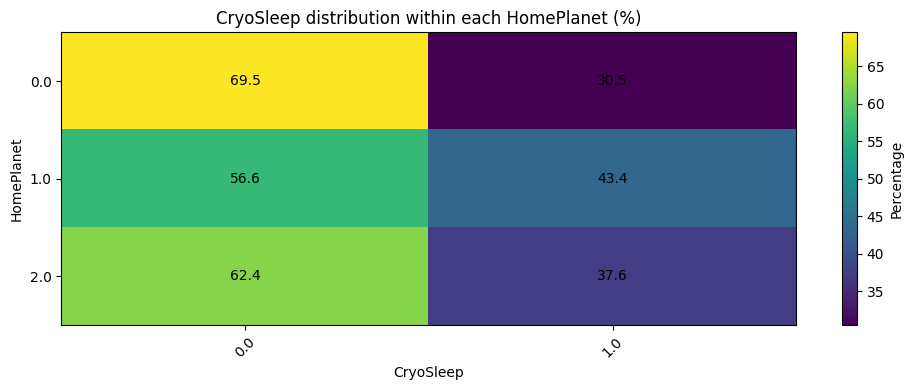

In [102]:
# Heatmap
plot_heatmap(
    cs_hp_values,
    cs_hp_rows,
    cs_hp_cols,
    title="CryoSleep distribution within each HomePlanet (%)",
    xlabel="CryoSleep",
    ylabel="HomePlanet"
)


מילוי 0 בכוכב אם 0

In [103]:
mask = (
    spaceship_data['CryoSleep'].isna() &
    (spaceship_data['HomePlanet'] == 0)
)

filled_count = int(mask.sum())

spaceship_data.loc[mask, 'CryoSleep'] = 0

print(f"Filled CryoSleep=0 for {filled_count} passengers from HomePlanet=0")


Filled CryoSleep=0 for 38 passengers from HomePlanet=0


מילוי שמי שלא בזבז כסף ישן במהלך הטיסה

In [104]:
spenders_mask = (
    spaceship_data['CryoSleep'].isna() &
    (spaceship_data['TotalSpend'] == 0)
)

filled_count = spenders_mask.sum()

spaceship_data.loc[spenders_mask, 'CryoSleep'] = 1

print(f"Sleeping money savers: {filled_count}")

Sleeping money savers: 19


כמה אנשים נשארו

In [105]:
missing_table(spaceship_data, "CryoSleep")

,Count
CryoSleep is NaN,0
CryoSleep not NaN,8693
Total rows,8693


------

### Cabin

בדיקה כמה חסר

In [106]:
missing_table(spaceship_data, "Cabin")

,Count
Cabin is NaN,199
Cabin not NaN,8494
Total rows,8693


##### הוספת ערך לCabin לפי GROUPID

In [107]:
group_stats = (
    spaceship_data
    .groupby('GroupId')['Cabin']
    .agg(
        unique_cabins=lambda x: x.dropna().nunique(),
        missing_cabins_count=lambda x: x.isna().sum()
    )
)

group_stats[group_stats['missing_cabins_count'] > 0].value_counts()


unique_cabins  missing_cabins_count
0              1                       99
1              1                       87
2              1                       10
3              1                        3
Name: count, dtype: int64

In [108]:
target_group_ids = group_stats[
    (group_stats['unique_cabins'] == 1) &
    (group_stats['missing_cabins_count'] > 0)
].index

pd.DataFrame({"Num_groups_to_fill": [len(target_group_ids)]})


,Num_groups_to_fill
0,87


In [109]:
fillable_rows = (
    spaceship_data[spaceship_data['GroupId'].isin(target_group_ids)]
    .sort_values(['GroupId'])
)

fillable_rows[['GroupId', 'Cabin']].head(4)


,GroupId,Cabin
103,110,NaN
104,110,B/5/P
105,110,B/5/P
106,110,B/5/P


In [110]:
mask = spaceship_data['GroupId'].isin(target_group_ids)

spaceship_data.loc[mask, 'Cabin'] = (
    spaceship_data.loc[mask]
    .groupby('GroupId')['Cabin']
    .transform(lambda x: x.ffill().bfill())
)


פיצול חוזר לערכי התא

In [111]:
spaceship_data['Deck'] = spaceship_data['Cabin'].str.split('/').str[0]
spaceship_data['RoomNum'] = spaceship_data['Cabin'].str.split('/').str[1].astype('float64')
spaceship_data['RoomSide'] = spaceship_data['Cabin'].str.split('/').str[2]

בדיקה סופית כמה חסר

In [112]:
missing_table(spaceship_data, "Cabin")

,Count
Cabin is NaN,112
Cabin not NaN,8581
Total rows,8693


------

### Destination


destination_map = {
    'TRAPPIST-1e': 0,
    'PSO J318.5-22': 1,
    '55 Cancri e': 2
}

בדיקה כמה חסר

In [113]:
missing_table(spaceship_data, "Destination")

,Count
Destination is NaN,182
Destination not NaN,8511
Total rows,8693


הצגת קשרים בין יתר העמודות 

בדיקת קשר לכוכב אם

In [114]:
# טבלת אחוזים: HomePlanet בתוך Destination
hp_dest_table, hp_dest_values, hp_dest_rows, hp_dest_cols = crosstab_percent(
    spaceship_data, "Destination", "HomePlanet"
)

hp_dest_table


HomePlanet,0.0,1.0,2.0
Destination,,,
0.0,52.43,20.10,27.47
1.0,91.29,2.40,6.31
2.0,38.88,50.28,10.84


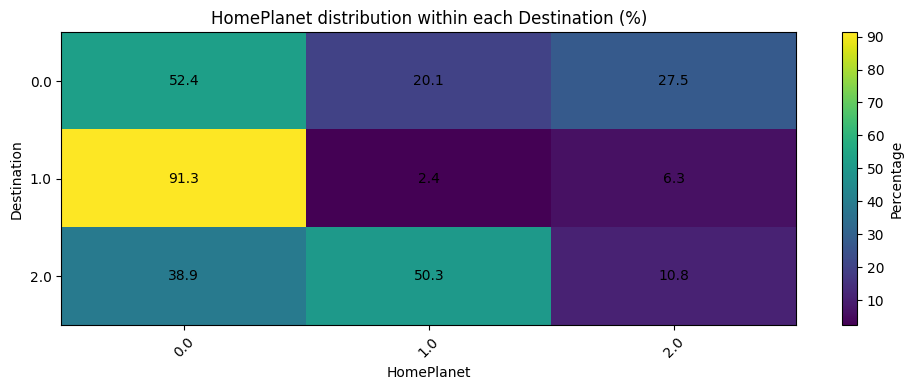

In [115]:
# Heatmap
plot_heatmap(
    hp_dest_values,
    hp_dest_rows,
    hp_dest_cols,
    title="HomePlanet distribution within each Destination (%)",
    xlabel="HomePlanet",
    ylabel="Destination"
)


91 אחוז שכוכב אם 0 מוביל ליעד 1

In [116]:
mask = (
    spaceship_data["HomePlanet"].isna() &
    (spaceship_data["Destination"] == 1)
)

filled_count = int(mask.sum())
spaceship_data.loc[mask, "HomePlanet"] = 0

print(f"Filled HomePlanet=0 for {filled_count} passengers with Destination=1")


Filled HomePlanet=0 for 4 passengers with Destination=1


קשר עם שינה

In [117]:
# טבלת אחוזים: CryoSleep בתוך Destination
cs_dest_table, cs_dest_values, cs_dest_rows, cs_dest_cols = crosstab_percent(
    spaceship_data, "Destination", "CryoSleep"
)

cs_dest_table


CryoSleep,0.0,1.0
Destination,,
0.0,68.13,31.87
1.0,51.88,48.12
2.0,58.50,41.50


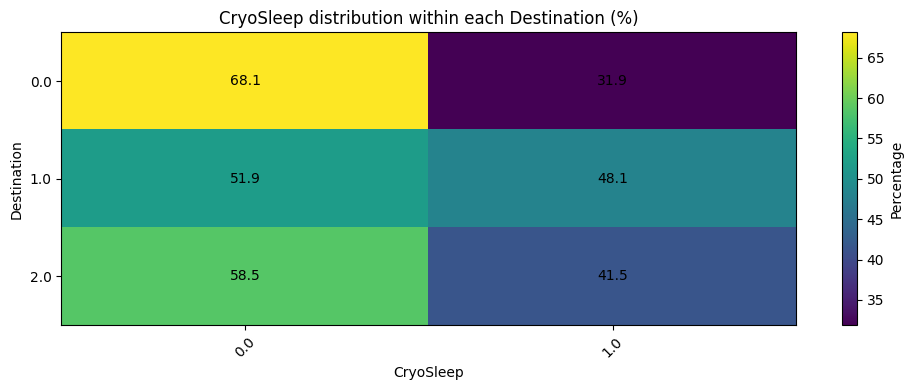

In [118]:
# Heatmap
plot_heatmap(
    cs_dest_values,
    cs_dest_rows,
    cs_dest_cols,
    title="CryoSleep distribution within each Destination (%)",
    xlabel="CryoSleep",
    ylabel="Destination"
)


קשר עם VIP

In [119]:
# טבלת אחוזים: Destination בתוך VIP
dest_vip_table, dest_vip_values, dest_vip_rows, dest_vip_cols = crosstab_percent(
    spaceship_data, "VIP", "Destination"
)

dest_vip_table


Destination,0.0,1.0,2.0
VIP,,,
0.0,69.83,9.32,20.85
1.0,57.87,9.14,32.99


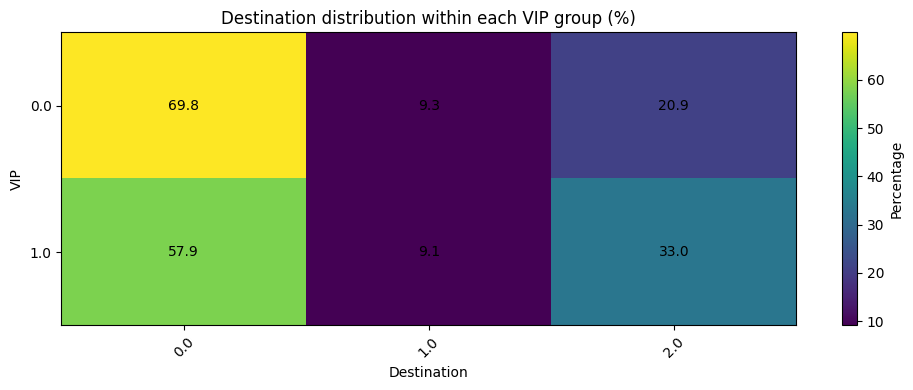

In [120]:
# Heatmap
plot_heatmap(
    dest_vip_values,
    dest_vip_rows,
    dest_vip_cols,
    title="Destination distribution within each VIP group (%)",
    xlabel="Destination",
    ylabel="VIP"
)


##### בדיקת כמות יעדים שיש לכל קבוצה 

In [121]:
dest_unique_per_group = (
    spaceship_data
    .dropna(subset=['Destination'])
    .groupby('GroupId')['Destination']
    .nunique()
)

dest_unique_per_group.value_counts().sort_index().to_frame('Num_groups')

,Num_groups
Destination,
1,5397
2,668
3,49


 יצירת מילון לזיהוי יעדים לפי קבוצה

In [122]:
fill_missing_by_group_unique(spaceship_data, "GroupId", "Destination")


 הוספת יעד לנוסעים שלקבוצתם יעד משותף

In [123]:
missing_table(spaceship_data, "Destination")


,Count
Destination is NaN,128
Destination not NaN,8565
Total rows,8693


##### מציאת יעד לפי נתוני הקבינה

מציאת שורות עם קבינה לא ריקה

In [124]:
deck_dest_table, deck_dest_values, deck_dest_rows, deck_dest_cols = crosstab_percent(
    spaceship_data.dropna(subset=["Cabin"]),
    "Deck",
    "Destination"
)

deck_dest_table


Destination,0.0,1.0,2.0
Deck,,,
A,55.38,0.77,43.85
B,55.67,0.38,43.95
C,55.20,1.87,42.93
D,72.50,3.54,23.96
E,81.59,4.83,13.58
F,76.53,8.95,14.52
G,67.24,18.19,14.57
T,100.00,0.00,0.00


מילוי קומה T ליעד 0

In [125]:
spaceship_data.loc[
    (spaceship_data["Deck"] == "T") &
    (spaceship_data["Destination"].isna()),
    "Destination"
] = 0

In [126]:
rs_dest_table, rs_dest_values, rs_dest_rows, rs_dest_cols = crosstab_percent(
    spaceship_data.dropna(subset=["Cabin"]),
    "RoomSide",
    "Destination"
)

rs_dest_table


Destination,0.0,1.0,2.0
RoomSide,,,
P,69.93,9.51,20.56
S,69.20,9.13,21.67


בדיקת חדרים לפי יעד שלהם

In [127]:
dest_per_cabin = (
    spaceship_data
    .dropna(subset=['Cabin'])
    .groupby('Cabin')['Destination']
    .nunique()
)

dest_per_cabin.value_counts().sort_index().to_frame("Num_cabins")

,Num_cabins
Destination,
0,103
1,5832
2,591
3,34


 יצירת מילון מקבינה לאן היעד שלה במקרה שכל חברי הקבינה לאותו המקום 

In [128]:
cabin_destination_map = (
    spaceship_data
    .dropna(subset=['Cabin', 'Destination'])
    .groupby('Cabin')['Destination']
    .agg(lambda s: s.iloc[0] if s.nunique() == 1 else np.nan)
)

 מילוי היעדים לכל מי שאפשר

In [129]:
mask = spaceship_data['Destination'].isna() & spaceship_data['Cabin'].notna()

spaceship_data.loc[mask, 'Destination'] = (
    spaceship_data.loc[mask, 'Cabin'].map(cabin_destination_map)
)

In [130]:
print("Missing Destination after cabin fill:", int(spaceship_data['Destination'].isna().sum()))

Missing Destination after cabin fill: 124


------------------------------

### Age

In [131]:
missing_table(spaceship_data, "Age")

,Count
Age is NaN,179
Age not NaN,8514
Total rows,8693


In [132]:
spaceship_data['GroupSize'] = spaceship_data.groupby('GroupId')['GroupId'].transform('size')
spaceship_data['IsAlone'] = (spaceship_data['GroupSize'] == 1).astype(int)


In [133]:
money_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

spaceship_data['TotalSpend'] = (
    spaceship_data[money_cols]
    .fillna(0)
    .sum(axis=1)
)


In [134]:
mask_ready = spaceship_data['Age'].notna() & spaceship_data['Deck'].notna()


In [135]:
eda_data = spaceship_data.loc[mask_ready, ['Age','GroupId','Deck','GroupSize','IsAlone','TotalSpend'] + money_cols]


בדיקת הוצאות כספים לפי גיל

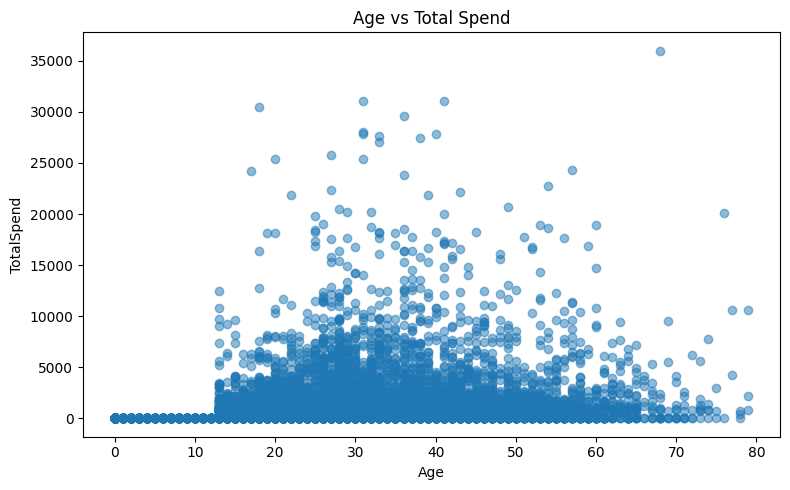

In [136]:
scatter_plot(
    spaceship_data,
    x_col="Age",
    y_col="TotalSpend",
    mask=mask_ready,
    title="Age vs Total Spend"
)


בדיקת קשרים עם יתר העמודות

בדיקה עם קומה

C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)


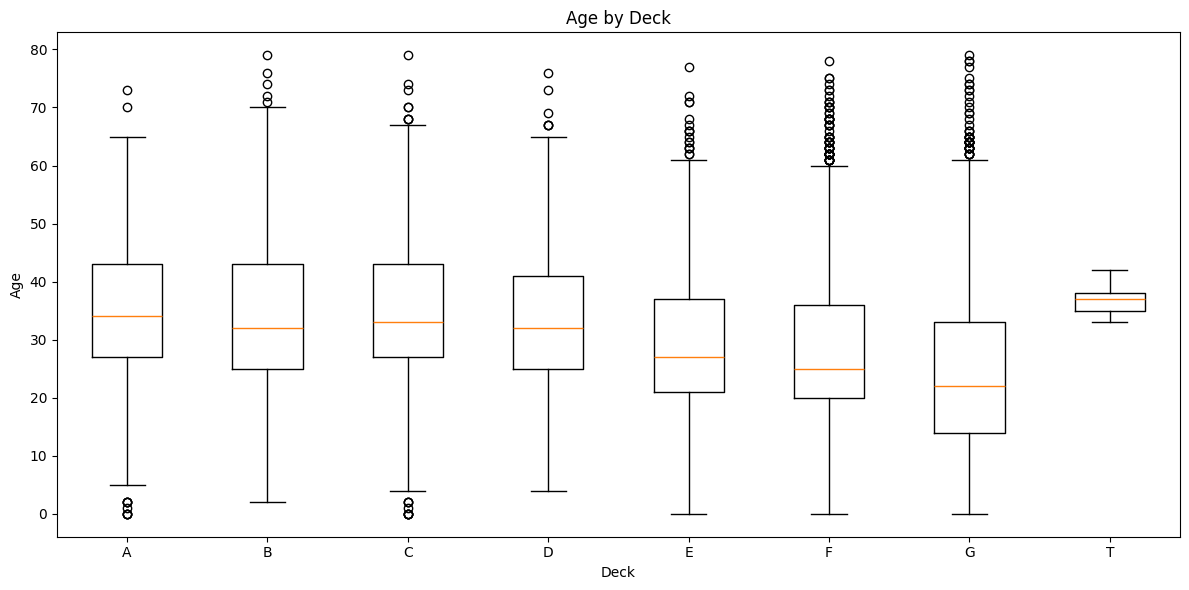

In [137]:
plot_box_subplots(
    spaceship_data,
    cols=["Age"],
    group_col="Deck",
    nrows=1,
    ncols=1,
    figsize=(12,6)
)


בדיקת עם כוכב אם

C:\Users\maxoo\AppData\Local\Temp\ipykernel_8224\1461217584.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=showfliers)


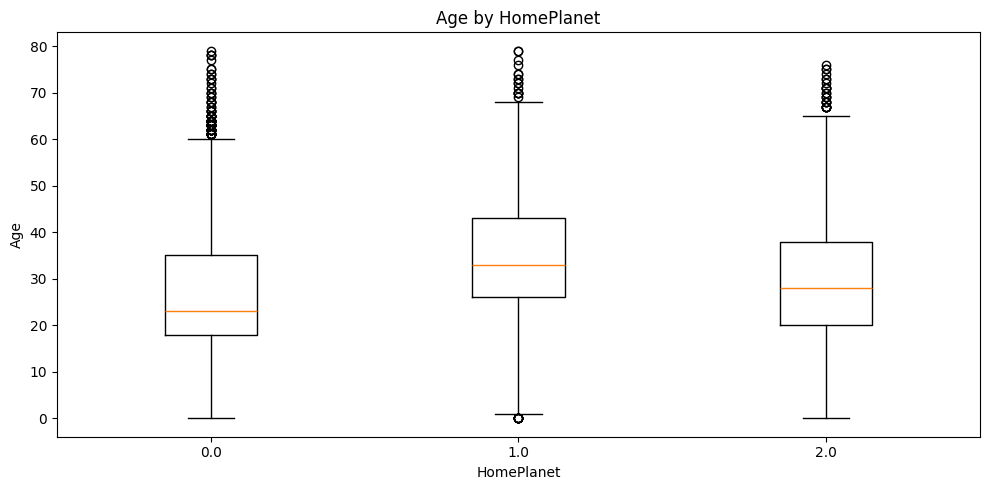

In [138]:
plot_box_subplots(
    spaceship_data,
    cols=["Age"],
    group_col="HomePlanet",
    nrows=1,
    ncols=1,
    figsize=(10,5)
)

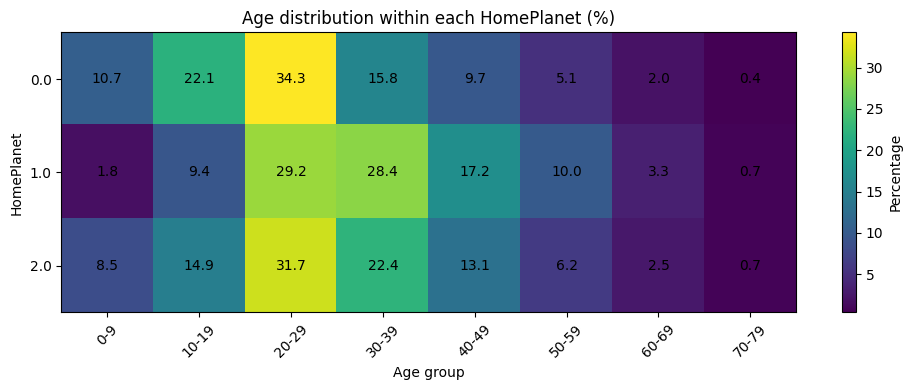

In [139]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 200]
labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

age_bin = pd.cut(spaceship_data["Age"], bins=bins, labels=labels, right=False)

tmp = pd.DataFrame({
    "HomePlanet": spaceship_data["HomePlanet"],
    "AgeBin": age_bin
})

age_hp_table, age_hp_values, age_hp_rows, age_hp_cols = crosstab_percent(tmp, "HomePlanet", "AgeBin")
age_hp_table

plot_heatmap(age_hp_values, age_hp_rows, age_hp_cols,
             title="Age distribution within each HomePlanet (%)",
             xlabel="Age group", ylabel="HomePlanet")


בדיקה עם יעד

In [140]:
# AgeBin מחוץ לדאטה
age_bin = pd.cut(
    spaceship_data["Age"],
    bins=bins,
    labels=labels,
    right=False
)

tmp = pd.DataFrame({
    "Destination": spaceship_data["Destination"],
    "AgeBin": age_bin
})

# טבלת אחוזים: AgeBin בתוך Destination
age_dest_table, age_dest_values, age_dest_rows, age_dest_cols = crosstab_percent(
    tmp, "Destination", "AgeBin"
)

age_dest_table


AgeBin,0-9,10-19,20-29,30-39,40-49,50-59,60-69,70-79
Destination,,,,,,,,
0.0,8.37,17.05,32.28,20.43,12.24,6.36,2.71,0.57
1.0,6.09,21.95,36.68,17.26,10.03,5.20,2.03,0.76
2.0,7.84,16.59,31.04,21.56,13.15,7.56,1.86,0.40


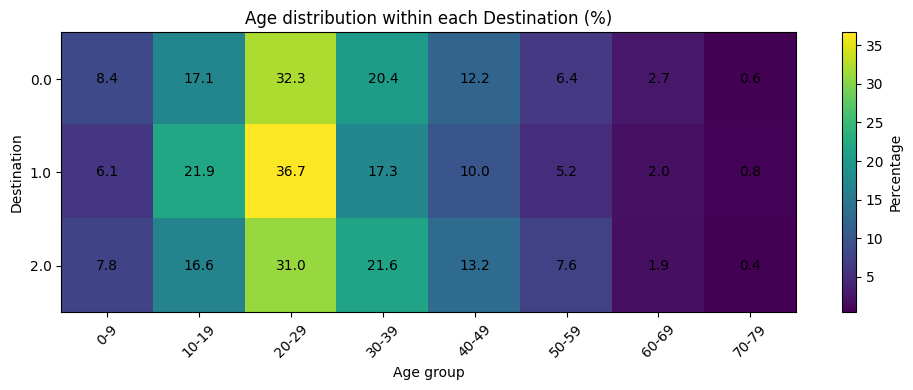

In [141]:
# Heatmap
plot_heatmap(
    age_dest_values,
    age_dest_rows,
    age_dest_cols,
    title="Age distribution within each Destination (%)",
    xlabel="Age group",
    ylabel="Destination"
)


בדיקה עם שינה

In [142]:
tmp = pd.DataFrame({
    "AgeBin": age_bin,
    "CryoSleep": spaceship_data["CryoSleep"]
})

cs_age_table, cs_age_values, cs_age_rows, cs_age_cols = crosstab_percent(
    tmp, "AgeBin", "CryoSleep"
)

cs_age_table


CryoSleep,0.0,1.0
AgeBin,,
0-9,51.10,48.90
10-19,58.55,41.45
20-29,68.68,31.32
30-39,67.78,32.22
40-49,67.08,32.92
50-59,66.79,33.21
60-69,66.35,33.65
70-79,69.57,30.43


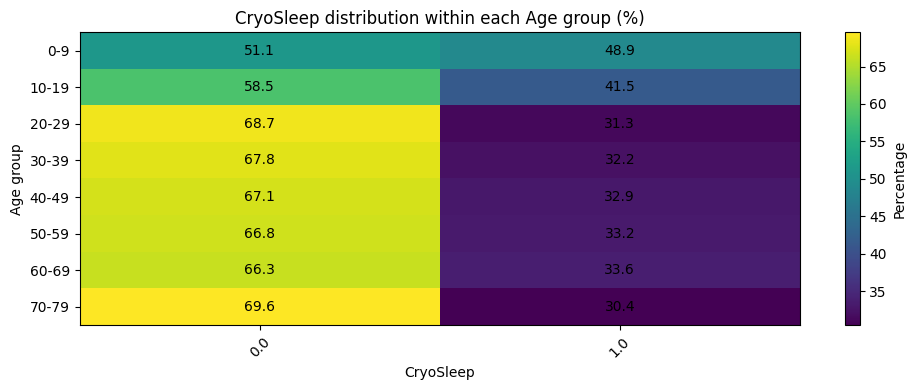

In [143]:
plot_heatmap(
    cs_age_values,
    cs_age_rows,
    cs_age_cols,
    title="CryoSleep distribution within each Age group (%)",
    xlabel="CryoSleep",
    ylabel="Age group"
)


In [144]:
spaceship_data['Age'] = spaceship_data.groupby('Deck')['Age'].transform(lambda x: x.fillna(x.median()))

### VIP

חיפוש כמה וי איי פי חסרים

In [145]:
vip_missing_table = (
    spaceship_data['VIP']
    .isna()
    .value_counts()
    .rename({True: "Missing", False: "Known"})
    .to_frame("Count")
)

vip_missing_table

,Count
VIP,
Known,8490
Missing,203


##### בדיקה בין ארץ מוצא לוי איי פי

In [146]:
tmp = spaceship_data[['HomePlanet', 'VIP']].dropna()

vip_hp_table = pd.crosstab(tmp['HomePlanet'], tmp['VIP'])
vip_hp_table

VIP,0.0,1.0
HomePlanet,,
0.0,4509,0
1.0,1971,132
2.0,1802,66


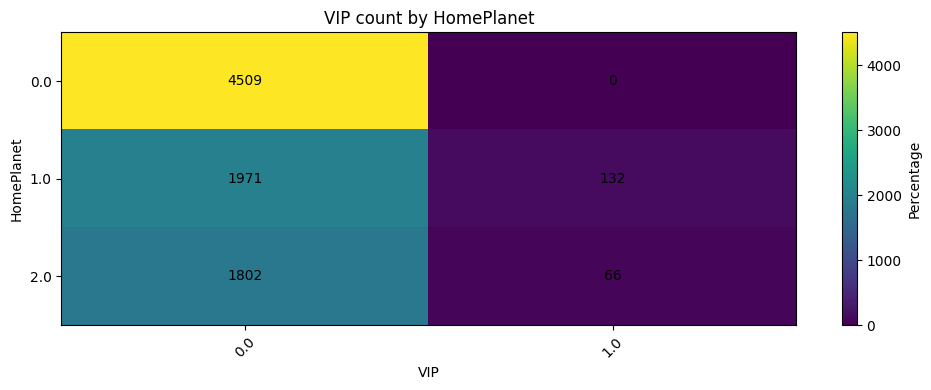

In [147]:
plot_heatmap(
    vip_hp_table.values,
    vip_hp_table.index.astype(str),
    vip_hp_table.columns.astype(str),
    title="VIP count by HomePlanet",
    xlabel="VIP",
    ylabel="HomePlanet",
    fmt="d"
)


כל הנוסעים מכדור הארץ אינם וי איי פי 

In [148]:
earth_mask = spaceship_data['VIP'].isna() & (spaceship_data['HomePlanet'] == 0)

spaceship_data.loc[earth_mask, 'VIP'] = 0



In [149]:
print(f"Filled VIP = 0 for Earth: {earth_mask.sum()}")


Filled VIP = 0 for Earth: 117


בדיקה עם וי איי פי 

The most young VIP: 18.0 years


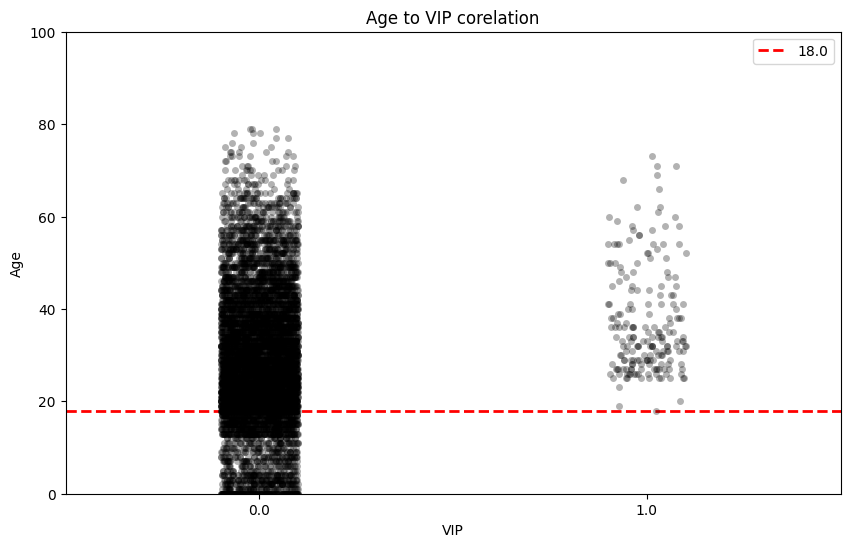

In [150]:
clean_data = spaceship_data.loc[
    (spaceship_data['Age'] != -1) & 
    (spaceship_data['VIP'] != -1)
]

min_vip_age = clean_data[clean_data['VIP'] == 1]['Age'].min()
print(f"The most young VIP: {min_vip_age} years")

plt.figure(figsize=(10, 6))
sns.stripplot(data=clean_data, x='VIP', y='Age', color='black', alpha=0.3, jitter=True)
plt.axhline(y=min_vip_age, color='red', linestyle='--', linewidth=2, label=min_vip_age)
plt.title('Age to VIP corelation')
plt.legend()
plt.ylim(0, 100) 
plt.show()

In [151]:
kids_mask = (spaceship_data['VIP']== -1) & (spaceship_data['Age'] < min_vip_age)
spaceship_data.loc[kids_mask, 'VIP'] = 0
print(f"VIP=False for kids: {kids_mask.sum()}")

VIP=False for kids: 0


חיבור עם שינה

In [152]:
tmp = spaceship_data[['CryoSleep', 'VIP']].dropna()

cryo_vip_table = pd.crosstab(tmp['CryoSleep'], tmp['VIP'])
cryo_vip_table

VIP,0.0,1.0
CryoSleep,,
0.0,5401,178
1.0,3007,21


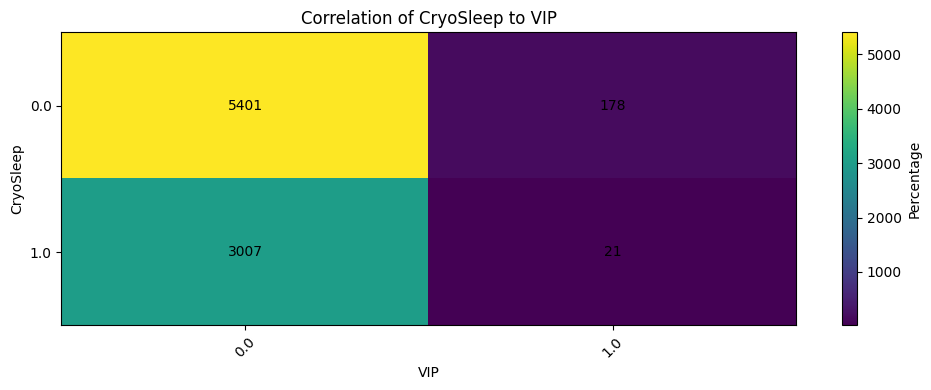

In [153]:
plot_heatmap(
    cryo_vip_table.values,
    cryo_vip_table.index.astype(str),
    cryo_vip_table.columns.astype(str),
    title="Correlation of CryoSleep to VIP",
    xlabel="VIP",
    ylabel="CryoSleep",
    fmt="d"
)


חיבור עם יעד

In [154]:
tmp = spaceship_data[['Destination', 'VIP']].dropna()

dest_vip_table = pd.crosstab(tmp['Destination'], tmp['VIP'])
dest_vip_table


VIP,0.0,1.0
Destination,,
0.0,5782,114
1.0,782,18
2.0,1722,65


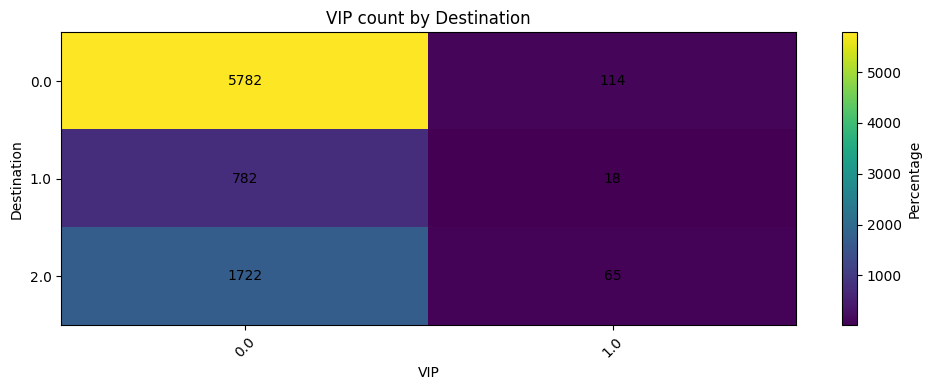

In [155]:
plot_heatmap(
    dest_vip_table.values,
    dest_vip_table.index.astype(str),
    dest_vip_table.columns.astype(str),
    title="VIP count by Destination",
    xlabel="VIP",
    ylabel="Destination",
    fmt="d"
)


-----------------------------

### MONEY

הוספת 0 לכל עמודה שביתר העמודות יש אפסים

In [156]:
money_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]


In [157]:
col_means = {}

for col in money_cols:
    valid = spaceship_data[(spaceship_data[col].notna()) & (spaceship_data[col] > 0)][col]
    col_means[col] = valid.mean()
    print(f"{col} mean (excluding 0 and NaN) = {col_means[col]}")

RoomService mean (excluding 0 and NaN) = 651.6323679727427
FoodCourt mean (excluding 0 and NaN) = 1276.436476751801
ShoppingMall mean (excluding 0 and NaN) = 508.6583850931677
Spa mean (excluding 0 and NaN) = 831.0706214689266
VRDeck mean (excluding 0 and NaN) = 861.3920265780731


הוספת ממוצע לכל עמודה לאנשים שמבזבזים כסף (לא כולל את האפסים)

In [158]:
for col in money_cols:
    mask_nan = spaceship_data[col].isna()
    other_cols = [c for c in money_cols if c != col]

    # לכל השורות שבהן col חסר, בדוק אם שאר העמודות כולן 0 (NaN נספר כ-0 רק לבדיקה)
    other_all_zero = spaceship_data.loc[mask_nan, other_cols].fillna(0).eq(0).all(axis=1)

    # אינדקסים למילוי 0
    idx_zero = spaceship_data.loc[mask_nan].index[other_all_zero]
    spaceship_data.loc[idx_zero, col] = 0

    # אינדקסים למילוי mean
    idx_mean = spaceship_data.loc[mask_nan].index[~other_all_zero]
    spaceship_data.loc[idx_mean, col] = col_means[col]


In [159]:
for col in money_cols:
    mask_nan = spaceship_data[col].isna()
    other_cols = [c for c in money_cols if c != col]

    # לכל השורות שבהן col חסר, בדוק אם שאר העמודות כולן 0 (NaN נספר כ-0 רק לבדיקה)
    other_all_zero = spaceship_data.loc[mask_nan, other_cols].fillna(0).eq(0).all(axis=1)

    # אינדקסים למילוי 0
    idx_zero = spaceship_data.loc[mask_nan].index[other_all_zero]
    spaceship_data.loc[idx_zero, col] = 0

    # אינדקסים למילוי mean
    idx_mean = spaceship_data.loc[mask_nan].index[~other_all_zero]
    spaceship_data.loc[idx_mean, col] = col_means[col]

In [160]:
print("Remaining NaNs in money columns:")
print(spaceship_data[money_cols].isna().sum())

Remaining NaNs in money columns:
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


-------------------

תיקוני דאטה

In [161]:
spaceship_data.replace(-1, np.nan).isna().sum().to_frame('Num_NaN')

,Num_NaN
HomePlanet,11
CryoSleep,0
Cabin,112
Destination,124
Age,112
VIP,86
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0


---------------------------------

## הורדת עמודות לא רלוונטיות

In [162]:
spaceship_data['TotalSpend'] = spaceship_data[money_cols].sum(axis=1)

In [163]:
final_data = spaceship_data.drop(columns=['Name', 'FirstName', 'Surname', 'Cabin', 'IsAlone']).copy()

In [164]:
final_data.replace(-1, np.nan, inplace=True)

In [165]:
final_data.isna().sum().to_frame('Num_NaN')

,Num_NaN
HomePlanet,11
CryoSleep,0
Destination,124
Age,112
VIP,86
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [166]:
deck_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4,
    'F': 5,
    'G': 6,
    'T': 7
}

roomside_map = {
    'P': 0,
    'S': 1
}

In [167]:
final_data['Deck'] = final_data['Deck'].map(deck_map)
final_data['RoomSide'] = final_data['RoomSide'].map(roomside_map)

In [168]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     8682 non-null   float64
 1   CryoSleep      8693 non-null   float64
 2   Destination    8569 non-null   float64
 3   Age            8581 non-null   float64
 4   VIP            8607 non-null   float64
 5   RoomService    8693 non-null   float64
 6   FoodCourt      8693 non-null   float64
 7   ShoppingMall   8693 non-null   float64
 8   Spa            8693 non-null   float64
 9   VRDeck         8693 non-null   float64
 10  Transported    8693 non-null   int64  
 11  TotalSpend     8693 non-null   float64
 12  GroupId        8693 non-null   int64  
 13  GroupMemberId  8693 non-null   int64  
 14  Deck           8581 non-null   float64
 15  RoomNum        8581 non-null   float64
 16  RoomSide       8581 non-null   float64
 17  GroupSize      8693 non-null   int64  
dtypes: float

## השלמות סופיות

כולם ללא הוצאות, כולם ללא vip

In [169]:
money_cols = ['TotalSpend']

mask = (final_data['VIP'] == 0) & (final_data['CryoSleep'] == 0)

all_zero = (
    (final_data.loc[mask, money_cols].fillna(0) == 0)
    .all(axis=1)
)

percent_all_zero = all_zero.mean() * 100

print(f"Out of non-VIP passengers who were NOT in CryoSleep:")
print(f"{percent_all_zero:.2f}% spent 0 in ALL money categories")


Out of non-VIP passengers who were NOT in CryoSleep:
10.63% spent 0 in ALL money categories


מחיקת השורות הנותרות שלא מצאנו להם שום קשר

In [170]:
final_data = final_data.dropna(subset=['CryoSleep'])

--------------------------------

##### homeplanet

מחיקת שורות שלא נמצא קשרים אליהם

In [171]:
final_data = final_data.dropna(subset=['HomePlanet'])

-----------------------------------

##### Destination

In [172]:
dest = final_data[final_data['Destination'].isna()]
print(f"Final NaNs in Destination: {final_data['Destination'].isna().sum()}")

Final NaNs in Destination: 123


מחיקת שורות ללא destination

In [173]:
final_data = final_data.dropna(subset=['Destination'])

In [174]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8559 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     8559 non-null   float64
 1   CryoSleep      8559 non-null   float64
 2   Destination    8559 non-null   float64
 3   Age            8452 non-null   float64
 4   VIP            8474 non-null   float64
 5   RoomService    8559 non-null   float64
 6   FoodCourt      8559 non-null   float64
 7   ShoppingMall   8559 non-null   float64
 8   Spa            8559 non-null   float64
 9   VRDeck         8559 non-null   float64
 10  Transported    8559 non-null   int64  
 11  TotalSpend     8559 non-null   float64
 12  GroupId        8559 non-null   int64  
 13  GroupMemberId  8559 non-null   int64  
 14  Deck           8452 non-null   float64
 15  RoomNum        8452 non-null   float64
 16  RoomSide       8452 non-null   float64
 17  GroupSize      8559 non-null   int64  
dtypes: float64(14

##### VIP

מילוי כל הנותרים כלא VIP

In [175]:
final_data.replace(np.nan, 0, inplace=True)

##### Age

מילוי גיל ממוצע בכל קומה 

In [176]:
final_data['Age'] = (
    final_data
    .groupby('Deck')['Age']
    .transform(lambda x: x.fillna(x.median()))
)


## One_hot Encoding

In [177]:
# יצירת עמודות one-hot
homeplanet_dummies = pd.get_dummies(
    final_data["HomePlanet"],
    prefix="HomePlanet"
)

destination_dummies = pd.get_dummies(
    final_data["Destination"],
    prefix="Destination"
)

# חיבור לעמודות המקוריות
final_data = pd.concat(
    [final_data, homeplanet_dummies, destination_dummies],
    axis=1
)

# מחיקת העמודות המקוריות (אם אתה רוצה)
final_data.drop(
    ["HomePlanet", "Destination"],
    axis=1,
    inplace=True
)


# בדיקה סופית ושמירת הדאטה

In [178]:
final_data.isna().sum().to_frame('Num_NaN')

,Num_NaN
CryoSleep,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0
Transported,0
TotalSpend,0


In [179]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8559 entries, 0 to 8692
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CryoSleep        8559 non-null   float64
 1   Age              8559 non-null   float64
 2   VIP              8559 non-null   float64
 3   RoomService      8559 non-null   float64
 4   FoodCourt        8559 non-null   float64
 5   ShoppingMall     8559 non-null   float64
 6   Spa              8559 non-null   float64
 7   VRDeck           8559 non-null   float64
 8   Transported      8559 non-null   int64  
 9   TotalSpend       8559 non-null   float64
 10  GroupId          8559 non-null   int64  
 11  GroupMemberId    8559 non-null   int64  
 12  Deck             8559 non-null   float64
 13  RoomNum          8559 non-null   float64
 14  RoomSide         8559 non-null   float64
 15  GroupSize        8559 non-null   int64  
 16  HomePlanet_0.0   8559 non-null   bool   
 17  HomePlanet_1.0   85

In [180]:
final_data.to_csv("../final_data.csv", index=False)
